In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
"""
import kagglehub
import shutil
import os

# --- CẤU HÌNH ---
# Tên thư mục bạn muốn lưu trữ kết quả cuối cùng
MY_DATA_FOLDER = "/content/drive/MyDrive/RAG-practice/my_fashion_data"

# 1. Tải dataset về bộ nhớ đệm (Cache)
print("⏳ Đang tải dataset từ Kaggle (có thể mất vài phút)...")
path_cache = kagglehub.dataset_download("agrigorev/clothing-dataset-full")
print(f"✅ Đã tải xong về cache tại: {path_cache}")

# 2. Tạo thư mục của riêng bạn
if not os.path.exists(MY_DATA_FOLDER):
    os.makedirs(MY_DATA_FOLDER)
    print(f"📁 Đã tạo thư mục mới: {MY_DATA_FOLDER}")

# 3. LỌC VÀ LẤY 2 CÁI CẦN THIẾT
print("\n🔄 Đang sao chép dữ liệu cần thiết...")

# --- Lấy cái 1: File CSV ---
src_csv = os.path.join(path_cache, "images.csv")
dst_csv = os.path.join(MY_DATA_FOLDER, "images.csv")

if os.path.exists(src_csv):
    shutil.copy(src_csv, dst_csv)
    print(f"👉 Đã lấy: images.csv")
else:
    print("❌ Lỗi: Không tìm thấy file csv trong dataset tải về.")

# --- Lấy cái 2: Folder ảnh nén (images_compressed) ---
src_imgs = os.path.join(path_cache, "images_compressed")
dst_imgs = os.path.join(MY_DATA_FOLDER, "images_compressed")

if os.path.exists(src_imgs):
    # Nếu thư mục đích đã có thì xóa đi copy lại cho sạch
    if os.path.exists(dst_imgs):
        shutil.rmtree(dst_imgs)

    shutil.copytree(src_imgs, dst_imgs)
    print(f"👉 Đã lấy: images_compressed (Toàn bộ ảnh nhẹ)")
else:
    print("❌ Lỗi: Không tìm thấy folder images_compressed.")

# 4. Kiểm tra kết quả
print("-" * 30)
print(f"🎉 HOÀN TẤT! Dữ liệu sạch của bạn nằm tại: {MY_DATA_FOLDER}")
print("Danh sách file trong thư mục của bạn:")
print(os.listdir(MY_DATA_FOLDER))

⏳ Đang tải dataset từ Kaggle (có thể mất vài phút)...
Using Colab cache for faster access to the 'clothing-dataset-full' dataset.
✅ Đã tải xong về cache tại: /kaggle/input/clothing-dataset-full
📁 Đã tạo thư mục mới: /content/drive/MyDrive/RAG-practice/my_fashion_data

🔄 Đang sao chép dữ liệu cần thiết...
👉 Đã lấy: images.csv
👉 Đã lấy: images_compressed (Toàn bộ ảnh nhẹ)
------------------------------
🎉 HOÀN TẤT! Dữ liệu sạch của bạn nằm tại: /content/drive/MyDrive/RAG-practice/my_fashion_data
Danh sách file trong thư mục của bạn:
['images.csv', 'images_compressed']


Tổng số dòng trong CSV: 5096
Số lượng ảnh sạch (có nhãn rõ ràng): 5096


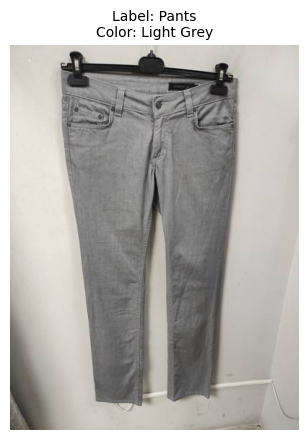

🖼 IMAGE ID: 1e9ba1e2-eefe-4853-ab05-63598cb144f1
🎨 Color: Light Grey
🏷 Label: Pants
📝 Caption:
Crafted from faded denim twill, the slim-leg silhouette features a mid-rise waist and classic five-pocket construction. Prominent topstitching, belt loops, and a zip-fly closure complete the contemporary casual aesthetic.

✅ Load ảnh + metadata thành công. Dữ liệu sẵn sàng cho Embedding / RAG.


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image

# ĐƯỜNG DẪN QUAN TRỌNG TRÊN COLAB
BASE_DIR = "/content/drive/MyDrive/RAG-practice/my_fashion_data"
CSV_PATH = os.path.join(BASE_DIR, "images.csv")
# Lưu ý: Chúng ta dùng images_compressed cho nhẹ, đừng dùng images_original
IMAGES_DIR = os.path.join(BASE_DIR, "images_compressed")

# 1. Đọc file CSV
df = pd.read_csv(CSV_PATH)
print(f"Tổng số dòng trong CSV: {len(df)}")

# 2. Lọc bỏ các nhãn nhiễu
df_clean = df[~df['label'].isin(['Not sure', 'Skip', 'Other'])]
print(f"Số lượng ảnh sạch (có nhãn rõ ràng): {len(df_clean)}")

# 3. Hàm lấy đường dẫn ảnh
# ==============================
def get_image_path(image_id):
    return os.path.join(IMAGES_DIR, f"{image_id}.jpg")

# ==============================
# 4. Test hiển thị ảnh + caption + color
# ==============================
try:
    row = df_clean.sample(1).iloc[0]
    img_path = get_image_path(row['image'])

    img = Image.open(img_path).convert("RGB")

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis('off')

    title_text = (
        f"Label: {row['label']}\n"
        f"Color: {row.get('color', 'N/A')}"
    )
    plt.title(title_text, fontsize=10)
    plt.show()

    print("🖼 IMAGE ID:", row['image'])
    print("🎨 Color:", row.get('color', 'N/A'))
    print("🏷 Label:", row['label'])
    print("📝 Caption:")
    print(row.get('caption', 'N/A'))

    print("\n✅ Load ảnh + metadata thành công. Dữ liệu sẵn sàng cho Embedding / RAG.")

except Exception as e:
    print(f"❌ Có lỗi xảy ra: {e}")
    print("👉 Kiểm tra lại images_compressed hoặc tên cột trong CSV.")


In [ ]:
# Kiểm tra ảnh bị thiếu
missing_images = []

for image_id in df_clean['image']:
    path = get_image_path(image_id)
    if not os.path.exists(path):
        missing_images.append(image_id)

print(f"Số ảnh bị thiếu file: {len(missing_images)}")


Số ảnh bị thiếu file: 0


In [ ]:
print("Các cột trong CSV:")
print(df.columns.tolist())


Các cột trong CSV:
['image', 'label', 'caption']


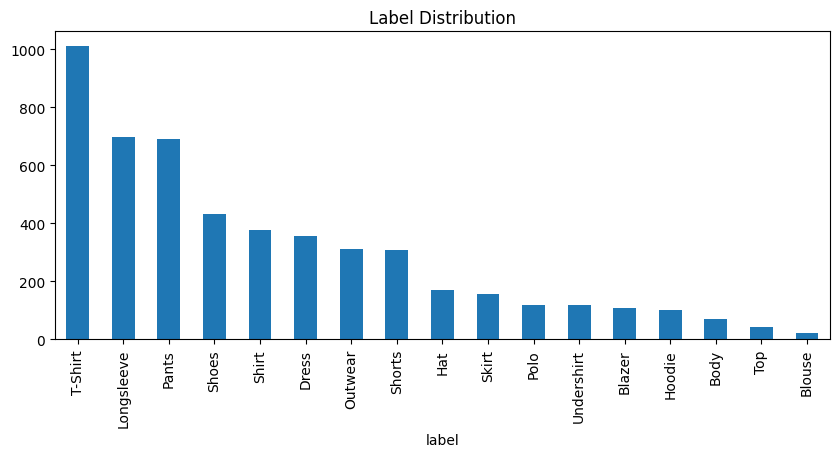

In [ ]:
df_clean['label'].value_counts().plot(kind='bar', figsize=(10,4))
plt.title("Label Distribution")
plt.show()


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5096 entries, 0 to 5095
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   image    5096 non-null   object
 1   label    5096 non-null   object
 2   caption  474 non-null    object
dtypes: object(3)
memory usage: 119.6+ KB


In [ ]:
df.head()


,image,label,caption
0,ea7b6656-3f84-4eb3-9099-23e623fc1018,T-Shirt,"Crafted from a smooth jersey knit, this fitted..."
1,ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa,T-Shirt,A short-sleeved knit top crafted from a mottle...
2,3b86d877-2b9e-4c8b-a6a2-1d87513309d0,Shoes,Supple leather ankle boots feature a pointed t...
3,5d3a1404-697f-479f-9090-c1ecd0413d27,Shorts,Crafted from a lightweight woven textile featu...
4,b0c03127-9dfb-4573-8934-1958396937bf,Shirt,An oversized silhouette in a brushed woven tex...


In [ ]:
df.isnull().sum()


,0
image,0
label,0
caption,0
color,15


In [ ]:
df[df['color'].isnull()]

,image,label,caption,color
5081,90a36044-7090-4bef-9159-6e2e3309234a,Shoes,"Molded polymeric footwear features a seamless,...",NaN
5082,0d1df3d4-ad7f-43f8-9673-90d368f6c853,T-Shirt,"This garment features a soft jersey knit, tail...",NaN
5083,36ad54ae-3450-4264-9655-4de51e6a1a32,Shirt,This woven garment features a subtle geometric...,NaN
5084,556817b5-b917-4502-a4c8-3deeff4684ab,Shoes,"A molded polymer construction shapes a wide, c...",NaN
5085,29cffc8e-5e72-4b73-bbc0-20b9f1251bc2,T-Shirt,"Crafted from a fluid, draped knit, this piece ...",NaN
5086,f4b934fc-e326-4f72-b535-53288b8b82d3,Skirt,"Crafted from a textured, breathable textile, t...",NaN
5087,575fc7c5-aa65-46c6-a343-35113c150129,Shirt,This woven short-sleeve button-down features a...,NaN
5088,acf7a391-8450-453d-898b-2a4a9d2886f6,Longsleeve,"Crafted from a soft jersey knit, this relaxed ...",NaN
5089,9bdac063-6c07-4bfc-a04a-e45224c503df,Undershirt,"Crafted from a soft, lightweight jersey knit, ...",NaN
5090,3855ea22-5e7f-411f-b1fa-6db27a676c06,Shoes,These miniature high-top profiles showcase a r...,NaN


In [ ]:
print("Số lượng label khác nhau:", df['label'].nunique())
df['label'].value_counts().head(17)


Số lượng label khác nhau: 17


,count
label,
T-Shirt,1011
Longsleeve,699
Pants,692
Shoes,431
Shirt,378
Dress,357
Outwear,312
Shorts,308
Hat,171


In [ ]:
dup_count = df_clean['image'].duplicated().sum()
print(f"Số image_id bị trùng: {dup_count}")


Số image_id bị trùng: 0


In [ ]:
from collections import Counter

sizes = []

for image_id in df_clean['image'].sample(100):  # sample cho nhanh
    img = Image.open(get_image_path(image_id))
    sizes.append(img.size)  # (width, height)

Counter(sizes).most_common(10)


[((400, 533), 47),
 ((400, 534), 17),
 ((533, 400), 9),
 ((534, 400), 3),
 ((400, 711), 2),
 ((400, 410), 2),
 ((400, 464), 1),
 ((711, 400), 1),
 ((400, 457), 1),
 ((400, 867), 1)]

In [ ]:
!pip install -q -U google-generativeai tqdm

In [ ]:
# 1. Loại bỏ các cột thừa
cols_to_remove = ['caption']
df_clean = df_clean.drop(columns=cols_to_remove, errors='ignore')




In [ ]:
# 3. Lưu đè lại vào file CSV để cập nhật thay đổi
df_clean.to_csv(CSV_PATH, index=False)
print(f"✅ Đã dọn dẹp và lưu file tại: {CSV_PATH}")

✅ Đã dọn dẹp và lưu file tại: /content/drive/MyDrive/RAG-practice/my_fashion_data/images.csv


In [ ]:

import google.generativeai as genai
import time
from tqdm import tqdm

# Cấu hình API
genai.configure(api_key="**REDACTED_GEMINI_API_KEY**") # Thay bằng key của bạn
model = genai.GenerativeModel('gemini-2.5-flash')

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:

# Test prompt
response = model.generate_content(
    "Viết 1 câu mô tả áo thun màu đỏ đô, phong cách casual."
)

print(response.text)

Dưới đây là một vài lựa chọn, tùy vào sắc thái bạn muốn nhấn mạnh:

1.  **Chiếc áo thun màu đỏ đô trầm ấm, với thiết kế casual đơn giản, mang lại vẻ ngoài thoải mái và năng động.** (Nhấn mạnh sự trầm ấm và năng động)
2.  **Tạo điểm nhấn tinh tế cho phong cách thường ngày với chiếc áo thun màu đỏ đô trầm ấm, form dáng casual thoải mái.** (Nhấn mạnh sự tinh tế và thoải mái)
3.  **Áo thun màu đỏ đô thanh lịch nhưng vẫn cực kỳ thoải mái, là lựa chọn hoàn hảo cho những ngày casual năng động.** (Nhấn mạnh sự kết hợp giữa thanh lịch và thoải mái)


In [ ]:
import os
import time
from tqdm import tqdm
from PIL import Image


# =====================================================
# 🧠 GENERATE FASHION SEARCH CAPTION
# =====================================================
def generate_search_caption(image_path: str) -> str | None:
    """
    Generate a fashion-centric morphological caption for a given image.
    Output: 30–40 words, professional fashion vocabulary.
    """

    prompt = """
    Write a 30-40 word fashion-centric morphological description.
    Focus:
    1. Fabric / Texture
    2. Silhouette / Fit
    3. Construction details (collars, seams, closures)
    4. Overall aesthetic

    Rules:
    - Use professional fashion vocabulary
    - NO colors
    - NO brand names
    - NO generic category names
    - Single paragraph only
    """

    try:
        img = Image.open(image_path)

        response = model.generate_content([prompt, img])

        caption = (
            response.text
            .strip()
            .replace("\n", " ")
            .replace("*", "")
        )

        return caption

    except Exception as e:
        print(f"❌ Lỗi xử lý ảnh {image_path}: {e}")
        return None


# =====================================================
# 📦 PREPARE DATAFRAME
# =====================================================
# Tạo cột caption nếu chưa tồn tại
if "caption" not in df_clean.columns:
    df_clean = df_clean.copy()  # tránh SettingWithCopyWarning
    df_clean["caption"] = None

# Chỉ xử lý các dòng còn thiếu caption
missing_captions = df_clean[df_clean["caption"].isna()]

print(f"🖼️ Cần xử lý: {len(missing_captions)} ảnh")


# =====================================================
# 🔁 MAIN PROCESS LOOP
# =====================================================
for idx, row in tqdm(
    missing_captions.iterrows(),
    total=len(missing_captions),
    desc="Generating captions"
):
    img_path = get_image_path(row["image"])

    if not os.path.exists(img_path):
        print(f"⚠️ Không tìm thấy ảnh: {img_path}")
        continue

    caption = generate_search_caption(img_path)
    if caption:
        df_clean.at[idx, "caption"] = caption

    # 💾 Lưu định kỳ mỗi 20 ảnh
    if idx % 20 == 0:
        df_clean.to_csv(CSV_PATH, index=False)

    # ⏳ Rate limit (Gemini Free ~15 RPM)
    time.sleep(1)


# =====================================================
# ✅ SAVE FINAL RESULT
# =====================================================
df_clean.to_csv(CSV_PATH, index=False)
print(f"✅ Hoàn tất! Caption đã được lưu vào: {CSV_PATH}")


🖼️ Cần xử lý: 0 ảnh


Generating captions: 0it [00:00, ?it/s]

✅ Hoàn tất! Caption đã được lưu vào: /content/drive/MyDrive/RAG-practice/my_fashion_data/images.csv


In [ ]:
def detect_item_color(image_path, label):
    """Nhận diện màu sắc chủ đạo của sản phẩm"""
    try:
        img = Image.open(image_path)

        # Prompt tập trung vào xác định màu sắc chính xác
        prompt = f"""
        Identify the primary color of this {label}.
        Rules:
        1. Return only the color name(s).
        2. Be specific (e.g., 'Olive Green' instead of just 'Green', 'Charcoal Grey' instead of 'Grey').
        3. If it has a pattern, mention the base color and the pattern type (e.g., 'White with Black stripes').
        4. Max 3-4 words. No full sentences.
        """

        response = model.generate_content([prompt, img])
        return response.text.strip().replace('*', '')
    except Exception as e:
        print(f"Lỗi nhận diện màu tại {image_path}: {e}")
        return None

In [ ]:
# --- CHUẨN BỊ CỘT COLOR ---
if 'color' not in df_clean.columns:
    df_clean['color'] = None

# Lọc các dòng chưa có màu sắc
missing_colors = df_clean[df_clean['color'].isna()]
print(f"Cần xử lý màu sắc cho: {len(missing_colors)} ảnh.")

# --- VÒNG LẶP XỬ LÝ ---
for index, row in tqdm(missing_colors.iterrows(), total=len(missing_colors)):
    img_path = get_image_path(row['image'])
    current_label = row['label']

    if os.path.exists(img_path):
        color_result = detect_item_color(img_path, current_label)

        if color_result:
            df_clean.loc[index, 'color'] = color_result

        # Lưu định kỳ
        if index % 20 == 0:
            df_clean.to_csv(CSV_PATH, index=False)

        # Rate limit an toàn (4s cho bản Free)
        time.sleep(1)

Cần xử lý màu sắc cho: 515 ảnh.


100%|██████████| 515/515 [1:04:29<00:00,  7.51s/it]


In [ ]:
# 1. Loại bỏ các cột thừa
cols_to_remove = ['sender_id', 'kids']
df_clean = df_clean.drop(columns=cols_to_remove, errors='ignore')




In [ ]:
# 2. Kiểm tra lại cấu trúc bảng
print("Cấu trúc bảng sau khi loại bỏ cột thừa:")
print(df_clean.info())
display(df_clean.head())


Cấu trúc bảng sau khi loại bỏ cột thừa:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5096 entries, 0 to 5095
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   image    5096 non-null   object
 1   label    5096 non-null   object
 2   caption  5096 non-null   object
dtypes: object(3)
memory usage: 119.6+ KB
None


,image,label,caption
0,ea7b6656-3f84-4eb3-9099-23e623fc1018,T-Shirt,"Women's t-shirt, rich burgundy red hue, soft s..."
1,ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa,T-Shirt,"Men's T-shirt, black and dark grey, textured d..."
2,3b86d877-2b9e-4c8b-a6a2-1d87513309d0,Shoes,"Black leather fitted ankle boots, pointed toe,..."
3,5d3a1404-697f-479f-9090-c1ecd0413d27,Shorts,"Men's dark blue shorts, abstract geometric lin..."
4,b0c03127-9dfb-4573-8934-1958396937bf,Shirt,"Relaxed fit flannel button-down shirt, red and..."


In [ ]:
# 3. Lưu đè lại vào file CSV để cập nhật thay đổi
df_clean.to_csv(CSV_PATH, index=False)
print(f"✅ Đã dọn dẹp và lưu file tại: {CSV_PATH}")

✅ Đã dọn dẹp và lưu file tại: /content/drive/MyDrive/RAG-practice/my_fashion_data/images.csv
